In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import os
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import  RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn import metrics


# Enable inline plotting for Jupyter notebooks
%matplotlib inline

In [2]:
file_path = 'wine.csv'
data2 = pd.read_csv(file_path)

In [3]:
data2.shape

(178, 14)

In [4]:
print("Dataset shape (rows, columns):", data2.shape)

Dataset shape (rows, columns): (178, 14)


In [5]:
list(data2.columns)

['Type',
 'Alcohol',
 'Malic',
 'Ash',
 'Alcalinity',
 'Magnesium',
 'Phenols',
 'Flavanoids',
 'Nonflavanoids',
 'Proanthocyanins',
 'Color',
 'Hue',
 'Dilution',
 'Proline']

In [6]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [7]:
print(f"Number of duplicated rows: {data2.duplicated().sum()}")

Number of duplicated rows: 0


In [8]:
print("\nMissing values per column:")
print(data2.isnull().sum())


Missing values per column:
Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64


In [9]:
for col in data2.columns:
    unique_value_list = data2[col].unique()
    if len(unique_value_list) > 10:
        print(f'{col} has {data2[col].nunique()} unique values')
    else:
        print(f'{col} contains:\t\t\t{unique_value_list}')

Type contains:			[1 2 3]
Alcohol has 126 unique values
Malic has 133 unique values
Ash has 79 unique values
Alcalinity has 63 unique values
Magnesium has 53 unique values
Phenols has 97 unique values
Flavanoids has 132 unique values
Nonflavanoids has 39 unique values
Proanthocyanins has 101 unique values
Color has 132 unique values
Hue has 78 unique values
Dilution has 122 unique values
Proline has 121 unique values


In [10]:
data2.duplicated().sum()

np.int64(0)

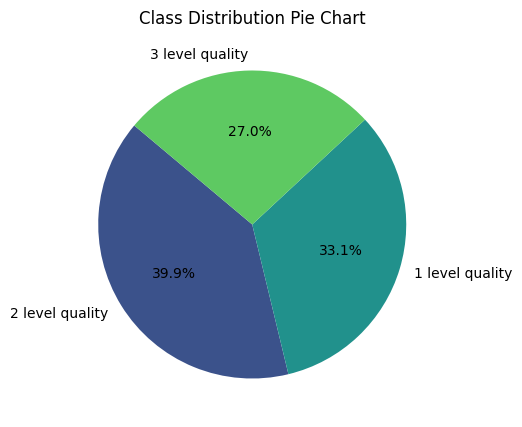

C:\Users\Jamal\AppData\Local\Temp\ipykernel_19144\2655536038.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=new_labels, y=class_counts, palette='viridis')


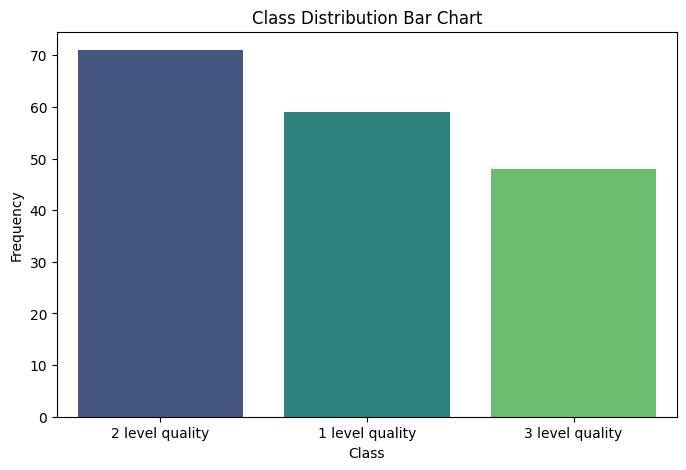

In [11]:
# Calculate the count of each class in the 'target' column
class_counts = data2['Type'].value_counts()

# Create a dictionary to map the existing numeric labels to new descriptive labels for visualization
labels = {
    1: '1 level quality',
    2: '2 level quality',
    3: '3 level quality'


    # Add more mappings as needed
}
# Map the numeric labels to descriptive labels for plotting
new_labels = [labels[i] for i in class_counts.index]

# Pie Chart for class distribution
plt.figure(figsize=(5, 5))
plt.pie(class_counts, labels=new_labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(class_counts)))
plt.title('Class Distribution Pie Chart')
plt.show()

# Bar Chart for class distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=new_labels, y=class_counts, palette='viridis')
plt.title('Class Distribution Bar Chart')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

In [12]:
# Automatically encode all object-type columns
label_encoders = {}
for col in data2.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data2[col] = le.fit_transform(data2[col])
    label_encoders[col] = le

In [13]:
# Creating holders to store the model performance results
ML_Model = []
ML_Config = []
accuracy = []
f1_score = []
recall = []
precision = []
auc_roc = []  # Adding a holder for AUC-ROC

# Function to call for storing the results
def storeResults(model,config, a, b, c, d, e):
    ML_Model.append(model)
    ML_Config.append(config)
    accuracy.append(round(a, 6))
    f1_score.append(round(b, 6))
    recall.append(round(c, 6))
    precision.append(round(d, 6))
    auc_roc.append(round(e, 6))

In [14]:
X = data2.drop(columns=["Type"])  # Replace with correct target if needed
y = data2["Type"]
# Step 1: Split the dataset into training and test sets (before any preprocessing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# SVM



=== SVM Model Performance with Hyperparameter Tuning ===

Running SVM with Original Data configuration...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Confusion Matrix (Test Data):
 [[17  0  2]
 [ 1 15  5]
 [ 1  5  8]]


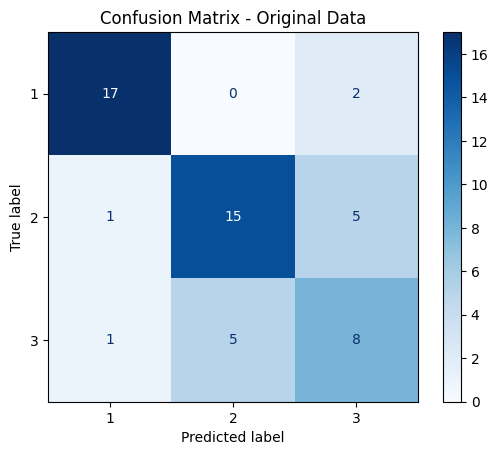


Support Vector Machine Model Performance Metrics
 Dataset  Accuracy  F1 Score   Recall  Precision  AUC-ROC
Training  0.838710  0.832325 0.831961   0.834162 0.959356
    Test  0.740741  0.726056 0.726817   0.726023 0.890123
Best hyperparameters found by GridSearchCV:
{'C': 1.0, 'coef0': 0.0, 'degree': 2, 'gamma': 0.001, 'kernel': 'rbf', 'probability': True}

Running SVM with Normalized Data configuration...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Confusion Matrix (Test Data):
 [[19  0  0]
 [ 0 21  0]
 [ 0  1 13]]


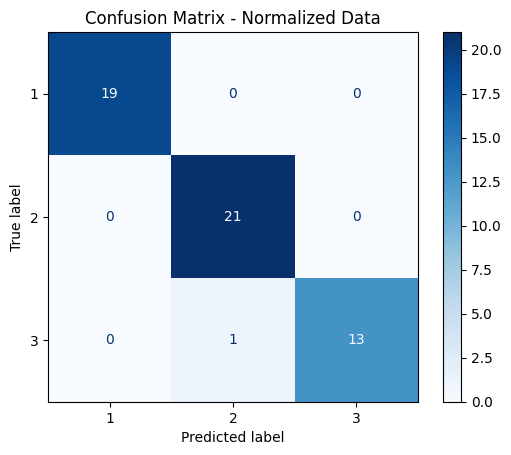


Support Vector Machine Model Performance Metrics
 Dataset  Accuracy  F1 Score  Recall  Precision  AUC-ROC
Training  1.000000  1.000000 1.00000   1.000000      1.0
    Test  0.981481  0.979902 0.97619   0.984848      1.0
Best hyperparameters found by GridSearchCV:
{'C': 1.0, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf', 'probability': True}


In [15]:


# Configuration list to store different data setups
configurations = []

# Configuration 1: Before any preprocessing (original data)
configurations.append(('Original Data', X_train, X_test, y_train))

# Step 2: Normalize the data
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)


configurations.append(('Normalized Data', X_train_normalized, X_test_normalized, y_train))





# Step 4: Run SVM with Hyperparameter Tuning on different configurations
print("\n=== SVM Model Performance with Hyperparameter Tuning ===")

# Defining an expanded parameter grid for hyperparameter tuning
# Perfect expanded parameter grid
param_grid = {
    'C': [1.0],                  # Regularization strength
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],  # Kernel coefficient
    'kernel': ['rbf'],          # Different kernel types
    'degree': [2, 3],                           # Only used for 'poly' kernel
    'coef0': [0.0, 0.1, 0.5,],
    'probability':[True],
    #'random_state': [RANDOM_STATE]
}

for name, X_train_cfg, X_test_cfg, y_train_cfg in configurations:
    print(f"\nRunning SVM with {name} configuration...")
    svc = GridSearchCV(SVC(probability=True), param_grid, cv=3, n_jobs=-1, verbose=2)
    svc.fit(X_train_cfg, y_train_cfg)

    y_train_svc = svc.predict(X_train_cfg)
    y_test_svc = svc.predict(X_test_cfg)


    y_train_svc_proba = svc.predict_proba(X_train_cfg)
    y_test_svc_proba = svc.predict_proba(X_test_cfg)


    # Confusion Matrix for Test Data
    cm = confusion_matrix(y_test, y_test_svc)
    print("\nConfusion Matrix (Test Data):\n", cm)

    # Plot Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svc.best_estimator_.classes_)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    # Computing the metrics for the Support Vector Machine model
    metrics_dict = {
        "Dataset": ["Training", "Test"],
        "Accuracy": [
            metrics.accuracy_score(y_train_cfg, y_train_svc),
            metrics.accuracy_score(y_test, y_test_svc),
        ],
        "F1 Score": [
                   metrics.f1_score(y_train_cfg, y_train_svc, average='macro'),
                       metrics.f1_score(y_test, y_test_svc, average='macro'),
                    ],
        "Recall": [
                metrics.recall_score(y_train_cfg, y_train_svc, average='macro'),
                   metrics.recall_score(y_test, y_test_svc, average='macro'),
               ],
               "Precision": [
              metrics.precision_score(y_train_cfg, y_train_svc, average='macro'),
                     metrics.precision_score(y_test, y_test_svc, average='macro'),
                       ],
         "AUC-ROC": [
                   metrics.roc_auc_score(pd.get_dummies(y_train_cfg), y_train_svc_proba, multi_class='ovr', average='macro'),
                  metrics.roc_auc_score(pd.get_dummies(y_test), y_test_svc_proba, multi_class='ovr', average='macro'),
               ]

    }

    # Converting the metrics into a pandas DataFrame for better display
    df_metrics = pd.DataFrame(metrics_dict)

    # Display the metrics DataFrame
    print("\nSupport Vector Machine Model Performance Metrics")
    print(df_metrics.to_string(index=False))

    # Storing the results, now including the AUC-ROC score
    auc_score = metrics.roc_auc_score(pd.get_dummies(y_test), y_test_svc_proba, multi_class='ovr', average='macro')
    storeResults( 'Support Vector Machine',name,
               metrics.accuracy_score(y_test, y_test_svc),
               metrics.f1_score(y_test, y_test_svc, average='macro'),
               metrics.recall_score(y_test, y_test_svc, average='macro'),
               metrics.precision_score(y_test, y_test_svc, average='macro'),auc_score
               )

    # Print the best hyperparameters
    print("Best hyperparameters found by GridSearchCV:")
    print(svc.best_params_)

# RF 


=== Random Forest Model Performance with Hyperparameter Tuning ===

Running Random Forest with Original Data configuration...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Confusion Matrix (Test Data):
 [[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]


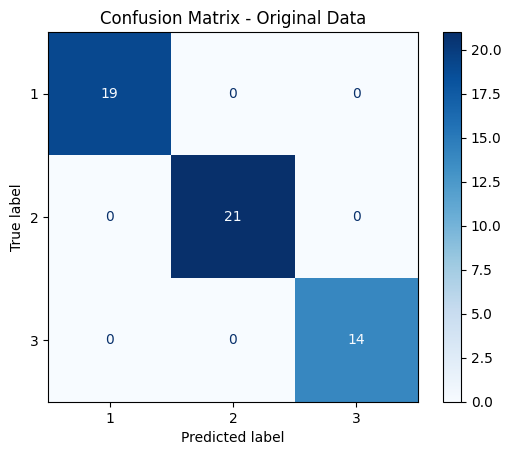


Random Forest Model Performance Metrics
 Dataset  Accuracy  F1 Score  Recall  Precision  AUC-ROC
Training       1.0       1.0     1.0        1.0      1.0
    Test       1.0       1.0     1.0        1.0      1.0

Running Random Forest with Normalized Data configuration...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Confusion Matrix (Test Data):
 [[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]


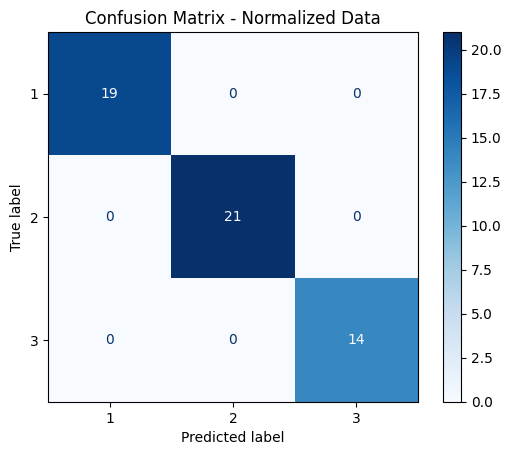


Random Forest Model Performance Metrics
 Dataset  Accuracy  F1 Score  Recall  Precision  AUC-ROC
Training       1.0       1.0     1.0        1.0      1.0
    Test       1.0       1.0     1.0        1.0      1.0
Best hyperparameters found by GridSearchCV:
{'bootstrap': True, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [16]:


# Configuration list to store different data setups
configurations = []

# Configuration 1: Before any preprocessing (original data)
configurations.append(('Original Data', X_train, X_test, y_train))

# Step 2: Normalize the data
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

# Configuration 2: After Normalization
configurations.append(('Normalized Data', X_train_normalized, X_test_normalized, y_train))



# Step 4: Run RandomForestClassifier with Hyperparameter Tuning on different configurations
print("\n=== Random Forest Model Performance with Hyperparameter Tuning ===")

# Defining an expanded parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'bootstrap': [True],
    'criterion': ['gini', 'entropy']
}


for name, X_train_cfg, X_test_cfg, y_train_cfg in configurations:
    print(f"\nRunning Random Forest with {name} configuration...")

    # GridSearchCV to find the best parameters for the RandomForestClassifier
    rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5,n_jobs=-1, verbose=1 )  # 5-fold cross-validation

    # Fitting the model for grid search with the training data
    rf.fit(X_train_cfg, y_train_cfg)

    # Predicting the target values for the training and test sets
    y_train_rf = rf.predict(X_train_cfg)
    y_test_rf = rf.predict(X_test_cfg)


    # Computing the probability scores for AUC-ROC (for the positive class)
    y_train_rf_proba = rf.predict_proba(X_train_cfg) # Probability scores for the positive class
    y_test_rf_proba = rf.predict_proba(X_test_cfg)
    # Confusion Matrix for Test Data  use RF predictions here
    cm = confusion_matrix(y_test, y_test_rf)
    print("\nConfusion Matrix (Test Data):\n", cm)

    # Plot Confusion Matrix  use RF estimator classes
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=rf.best_estimator_.classes_)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # Computing the metrics for the Random Forest model
    metrics_dict = {
        "Dataset": ["Training", "Test"],
        "Accuracy": [
            metrics.accuracy_score(y_train_cfg, y_train_rf),
            metrics.accuracy_score(y_test, y_test_rf),
        ],
        "F1 Score": [
                   metrics.f1_score(y_train_cfg, y_train_rf, average='macro'),
                       metrics.f1_score(y_test, y_test_rf, average='macro'),
                    ],
        "Recall": [
                   metrics.recall_score(y_train_cfg, y_train_rf, average='macro'),
                   metrics.recall_score(y_test, y_test_rf, average='macro'),
          ],
          "Precision": [
                   metrics.precision_score(y_train_cfg, y_train_rf, average='macro'),
                   metrics.precision_score(y_test, y_test_rf, average='macro'),
         ],
         "AUC-ROC": [
                   metrics.roc_auc_score(pd.get_dummies(y_train_cfg), y_train_rf_proba, multi_class='ovr', average='macro'),
                   metrics.roc_auc_score(pd.get_dummies(y_test), y_test_rf_proba, multi_class='ovr', average='macro'),
         ]

    }

    # Converting the metrics into a pandas DataFrame for better display
    df_metrics = pd.DataFrame(metrics_dict)

    # Display the metrics DataFrame
    print("\nRandom Forest Model Performance Metrics")
    print(df_metrics.to_string(index=False))
    auc_score = metrics.roc_auc_score(pd.get_dummies(y_test), y_test_rf_proba, multi_class='ovr', average='macro')
    # Storing the results, now including the AUC-ROC score
    storeResults('Random Forest', name,
             metrics.accuracy_score(y_test, y_test_rf),
             metrics.f1_score(y_test, y_test_rf, average='macro'),
             metrics.recall_score(y_test, y_test_rf, average='macro'),
             metrics.precision_score(y_test, y_test_rf, average='macro'),
             auc_score)

# Print the best hyperparameters
print("Best hyperparameters found by GridSearchCV:")
print(rf.best_params_)



In [17]:
# Creating the dataframe

# Make sure output folder exists
out_dir = Path("final_results")
out_dir.mkdir(parents=True, exist_ok=True)

result = pd.DataFrame({
    'ML Model': ML_Model,
    'Configuration': ML_Config,
    'Accuracy': [f"{acc * 100:.3f}%" for acc in accuracy],
    'F1 Score': [f"{f1 * 100:.3f}%" for f1 in f1_score],
    'Recall': [f"{rec * 100:.3f}%" for rec in recall],
    'Precision': [f"{prec * 100:.3f}%" for prec in precision],
    'ROC_AUC': [f"{roc * 100:.3f}%" for roc in auc_roc],
})

# Remove duplicates based on model and configuration
result.drop_duplicates(subset=["ML Model", "Configuration"], inplace=True)

# Display the result
print("\n" + "=" * 100)
print("MODEL PERFORMANCE RESULTS")
print("=" * 100)
print(result.to_string(index=False))

# Save the result to a CSV file
result.to_csv('final_results/model_results.csv', index=False)
print("\nResults saved to model_results.csv")

# Sort by Accuracy and F1 Score
sorted_result = result.sort_values(by=['Accuracy', 'F1 Score'], ascending=False).reset_index(drop=True)

# Display the sorted result
print("\n" + "=" * 100)
print("SORTED MODEL PERFORMANCE RESULTS (by Accuracy and F1 Score)")
print("=" * 100)
print(sorted_result.to_string(index=False))

# Save the sorted result
sorted_result.to_csv('final_results/sorted_model_results.csv', index=True)
print("\nSorted results saved to sorted_model_results.csv")

# Extract top configuration per ML model
top_per_model = sorted_result.groupby('ML Model', as_index=False).first()

# Display and save the top configuration table
print("\n" + "=" * 100)
print("TOP CONFIGURATION PER MODEL")
print("=" * 100)
print(top_per_model.to_string(index=False))

top_per_model.to_csv('final_results/top_configurations.csv', index=False)
print("\nTop configuration per model saved to top_configurations.csv")


MODEL PERFORMANCE RESULTS
              ML Model   Configuration Accuracy F1 Score   Recall Precision  ROC_AUC
Support Vector Machine   Original Data  74.074%  72.606%  72.682%   72.602%  89.012%
Support Vector Machine Normalized Data  98.148%  97.990%  97.619%   98.485% 100.000%
         Random Forest   Original Data 100.000% 100.000% 100.000%  100.000% 100.000%
         Random Forest Normalized Data 100.000% 100.000% 100.000%  100.000% 100.000%

Results saved to model_results.csv

SORTED MODEL PERFORMANCE RESULTS (by Accuracy and F1 Score)
              ML Model   Configuration Accuracy F1 Score   Recall Precision  ROC_AUC
Support Vector Machine Normalized Data  98.148%  97.990%  97.619%   98.485% 100.000%
Support Vector Machine   Original Data  74.074%  72.606%  72.682%   72.602%  89.012%
         Random Forest   Original Data 100.000% 100.000% 100.000%  100.000% 100.000%
         Random Forest Normalized Data 100.000% 100.000% 100.000%  100.000% 100.000%

Sorted results saved to s